# 02. 모델링 — NASA C-MAPSS FD001 (Step 04)

**목적:** 전처리 데이터셋으로 baseline부터 기본 회귀 모델까지 학습하고, 동일 기준으로 비교한다.

**원칙 (GPT 검토 반영)**
- baseline부터 시작 (복잡한 모델 먼저 X)
- test 평가는 **engine_id별 마지막 cycle 행**만 사용 → RUL_FD001.txt의 true RUL과 비교
- RMSE/MAE뿐 아니라 **RUL≤30 조기경보 Recall / FNR**을 함께 본다 (고장 임박 놓침 = 가장 위험)

**범위:** 기본 회귀 모델 비교까지. 하이퍼파라미터 튜닝·딥러닝·앙상블 최적화는 이후 단계.

> 학습 타깃은 RUL_clipped(cap=125). test의 true RUL은 원본이므로, 비교를 위해 예측값도 [0,125]로 클리핑해 평가한다(타깃 정의와 평가 기준 일치).


## 1. 셋업 및 데이터 로딩

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from modeling import run_all_models, get_test_last_cycle, ALERT_THRESHOLD
from preprocess import RUL_CAP

sns.set_theme(style="whitegrid")


## 2. 모델 학습 및 평가

baseline 2종(평균, cycle 선형회귀) + 회귀 4종(Linear, Ridge, RandomForest, GradientBoosting)을 학습하고, test 엔진 100대의 마지막 시점 RUL을 예측해 true RUL과 비교한다.


In [2]:
results_df, preds, y_true, test_last = run_all_models(ROOT)
results_df


,RMSE,MAE,NASA_Score,Alert_Recall,FNR,n_actual_alert,FN_count
model,,,,,,,
Baseline_mean,43.07,35.90,33629.2,0.00,1.00,25.0,25.0
Baseline_cycle_LR,33.34,27.59,5318.9,0.04,0.96,25.0,24.0
LinearRegression,21.69,17.44,1287.5,0.36,0.64,25.0,16.0
Ridge,21.69,17.44,1285.3,0.36,0.64,25.0,16.0
RandomForest,18.16,13.24,950.5,0.72,0.28,25.0,7.0
GradientBoosting,18.39,13.09,1144.0,0.72,0.28,25.0,7.0


## 3. 모델별 성능 비교

- **RMSE / MAE**: 회귀 정확도 (낮을수록 좋음)
- **NASA_Score**: 늦은 예측(과대 예측)에 더 큰 패널티 (낮을수록 좋음)
- **Alert_Recall**: 실제 고장임박(RUL≤30)을 잡은 비율 (높을수록 좋음)
- **FNR**: 고장임박을 정상으로 놓친 비율 (낮을수록 좋음, **이 프로젝트에서 가장 중요**)


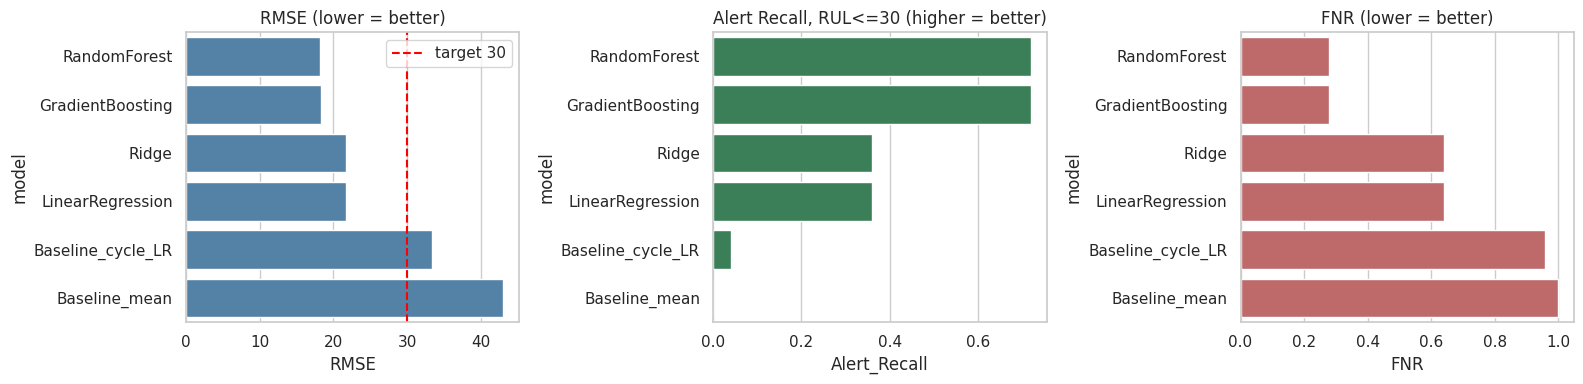

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

order = results_df.sort_values("RMSE").index
sns.barplot(x=results_df.loc[order, "RMSE"], y=order, color="steelblue", ax=axes[0])
axes[0].set_title("RMSE (lower = better)"); axes[0].axvline(30, color="red", ls="--", label="target 30")
axes[0].legend()

sns.barplot(x=results_df.loc[order, "Alert_Recall"], y=order, color="seagreen", ax=axes[1])
axes[1].set_title("Alert Recall, RUL<=30 (higher = better)")

sns.barplot(x=results_df.loc[order, "FNR"], y=order, color="indianred", ax=axes[2])
axes[2].set_title("FNR (lower = better)")
plt.tight_layout(); plt.show()


## 4. 예측값 vs 실제값 산점도

대각선(y=x)에 가까울수록 정확하다. 빨간 영역(RUL≤30)은 고장 임박 구간으로, 이 구간에서 예측이 실제보다 높으면(점이 대각선 위쪽) 위험한 과대 예측(놓침)이다.


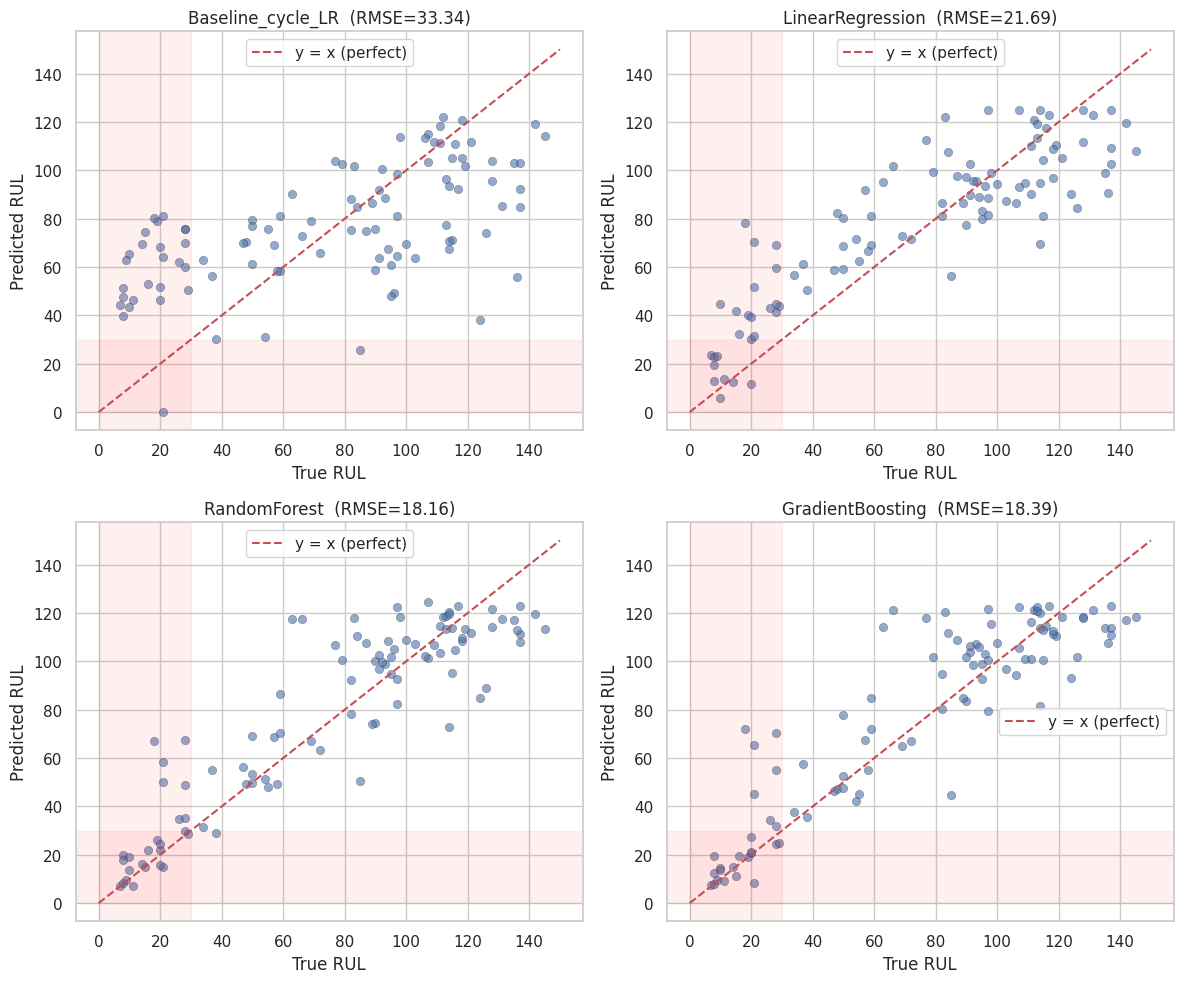

In [4]:
key_models = ["Baseline_cycle_LR", "LinearRegression", "RandomForest", "GradientBoosting"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.ravel(), key_models):
    ax.scatter(y_true, preds[name], alpha=0.6, edgecolor="k", linewidth=0.3)
    lim = [0, max(y_true.max(), RUL_CAP) + 5]
    ax.plot(lim, lim, "r--", label="y = x (perfect)")
    ax.axhspan(0, ALERT_THRESHOLD, color="red", alpha=0.06)
    ax.axvspan(0, ALERT_THRESHOLD, color="red", alpha=0.06)
    ax.set_title(f"{name}  (RMSE={results_df.loc[name,'RMSE']})")
    ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL"); ax.legend()
plt.tight_layout(); plt.show()


## 5. 모델별 장단점 정리

| 모델 | 장점 | 단점 |
|---|---|---|
| Baseline (평균) | 최소 기준선 | 정보 없음, 조기경보 전혀 못 잡음 |
| Baseline (cycle LR) | 단순, cycle만으로 약한 신호 | 센서 미사용, 성능 낮음 |
| Linear / Ridge | 빠르고 해석 쉬움 | 비선형 열화 패턴 못 잡음 |
| RandomForest | 비선형 포착, RMSE·Recall 우수 | 외삽 약함, 모델 큼 |
| GradientBoosting | RandomForest와 유사, MAE 우수 | 학습 느림, 튜닝 민감 |

**관찰:** 트리 기반 모델(RF/GB)이 baseline·선형 대비 RMSE와 조기경보 Recall 모두 크게 앞선다. 다만 FNR은 아직 목표(≤5%)에 못 미치므로, 다음 단계에서 임계값 조정·시계열 피처·튜닝으로 FN을 더 줄여야 한다. (현 단계 결론을 과장하지 않는다.)

상세 해석: `docs/04_modeling_summary.md`
